## Generic Plot (Initial visualisation)

In [1]:
import numpy as np
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader
from redoxed.plots import GenericPlot, EfficiencyPlot
from redoxed import config
config.set_latex_mode(False)  

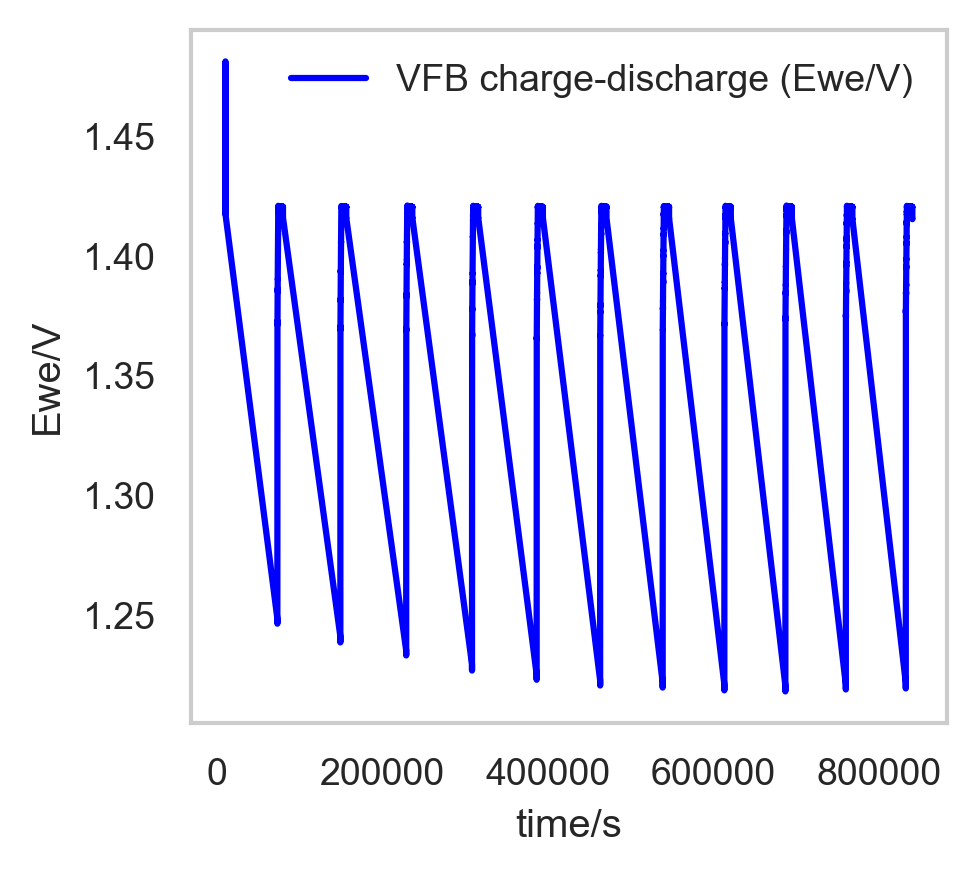

In [2]:
fpath=r"C:\Users\es758\Downloads\1_VFB_22rpm_06_GCPL_C04.mpr"
# fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_03_GCPL_C04.mpr"
loader = LoaderFactory.get_loader(fpath)
data = loader.load_data(fpath=fpath)

#data.df.iloc[10:20]

GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", y2_col="control/V/mA")
GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V")
GenericPlot_object.add_plot(data.df, linestyle = "-", marker = "", color1 = 'blue', color2='red', label = "VFB charge-discharge")
GenericPlot_object.ax.legend()
display(GenericPlot_object.fig)

## Polarisation

,flags,Ns,time/s,dq/mA.h,(Q-Qo)/mA.h,control/V/mA,Ewe/V,I Range,Q charge/discharge/mA.h,half cycle
0,19,0,54814.464065,0.0,0.000000,0.0,0.011835,14,0.0000,0
1,19,0,54815.464065,0.0,0.000000,0.0,0.002022,14,0.0000,0
2,19,0,54816.464065,0.0,0.000000,0.0,0.000456,14,0.0000,0
3,19,0,54817.464065,0.0,0.000000,0.0,0.000265,14,0.0000,0
4,19,0,54818.464065,0.0,0.000000,0.0,0.000131,14,0.0000,0
...,...,...,...,...,...,...,...,...,...,...
10245,19,32,55941.512067,0.0,-0.111356,0.0,-0.004014,14,-3.3381,31
10246,19,32,55942.512067,0.0,-0.111356,0.0,-0.001798,14,-3.3381,31
10247,19,32,55943.512067,0.0,-0.111356,0.0,-0.001664,14,-3.3381,31
10248,19,32,55944.414267,0.0,-0.111356,0.0,-0.001894,14,-3.3381,31


(39, 10)


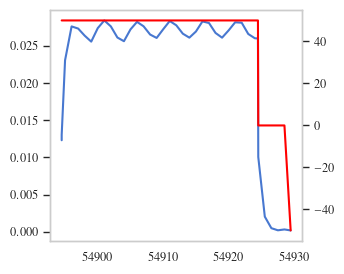

2.7165186 0.0010377836 -5.4152217e-05
[-80. -75. -70. -65. -60. -55. -50. -45. -40. -35. -30. -25. -20. -15.
 -10.  -5.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.
  65.  70.  75.  80.]


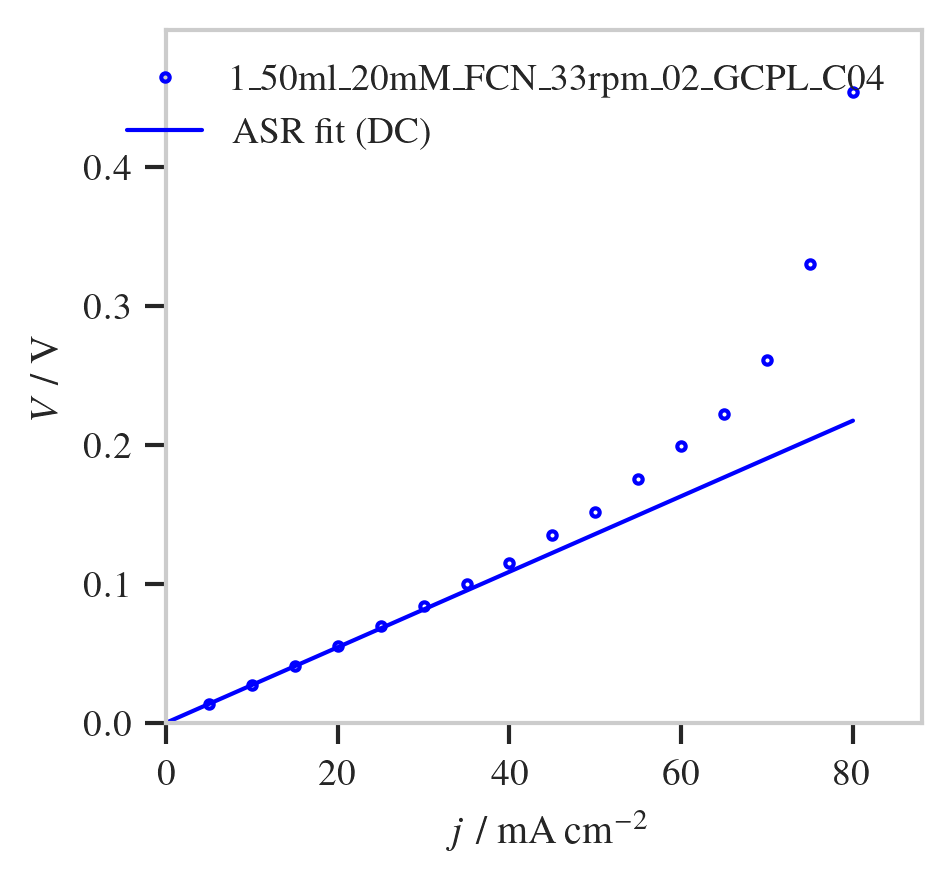

In [2]:
from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData
from redoxed.dc import PolarisationData
import matplotlib.pyplot as plt
import numpy as np

from redoxed import config
config.set_latex_mode(True)  

### polarisation
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\1_50ml_20mM_FCN_33rpm_02_GCPL_C04.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
display(ECData_object.df)

### Decide range to extract
fig, ax = plt.subplots(1, 1, figsize = (3.25,3), dpi = 100)
ax_I = ax.twinx()

df = ECData_object.df.copy()
df = df.loc[df['half cycle'] == 2]
# df = df.loc[df['half cycle'] >= 24]
# df = df.loc[df['half cycle'] <= 24]
print(df.shape)
ax_I.plot(df['time/s'], df['control/V/mA'], color = 'red')
ax.plot(df['time/s'], df['Ewe/V'])
plt.close(fig)
display(fig)


# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
PolarisationData_object = ECData_object.to_PolarisationData(A=5, pulse_index_range=(-10,None))

data_plot = PolarisationPlot(figsize=(3.25, 3), dpi=300) 
data_plot.add_plot(PolarisationData_object, linestyle = "", marker = "o", markersize = 2, markerfacecolor = 'none', markeredgecolor = 'blue', color = 'blue')#, label="data")
PolarisationData_object.calculate_ASR(restrict_to_zero=False, j_range=(-10,10))
j_pred = np.sort(PolarisationData_object.j)
V_pred = PolarisationData_object.ASR*j_pred/1000 # account for mA
PolarisationData_object_fit = PolarisationData(j=j_pred, V=V_pred, A=5)
data_plot.add_plot(PolarisationData_object_fit, linestyle = "-", marker = "", linewidth = 1, color = 'blue', label = "ASR fit (DC)")
print(PolarisationData_object.ASR, PolarisationData_object.ASR_error, PolarisationData_object.ASR_intercept)
print(PolarisationData_object_fit.j)


# ### EIS quantities
# j_model = j_pred[j_pred >= 0]
# j_model = np.insert(j_model, 0,0)

# V_pos_comps = []

# # remember series resistance
# # V_pos_comps.append(DRT_object.R_0*5*j_pos/1000)
# for i, R in enumerate(Z_list):
#     #print(R)
#     ASR = R*PolarisationData_object.A
#     V_i_pos = ASR*j_model/1000
#     # V_i_pos = R_EIS_total*5*j_pos/1000
#     V_pos_comps.append(V_i_pos)
#     #labels.append(str(i))

# data_plot.ax.stackplot(j_model, V_pos_comps, labels=labels, alpha = 0.6, colors=color_list)

data_plot.ax.set_xlim([0, None])
data_plot.ax.set_ylim([0, None])

data_plot.ax.legend()
display(data_plot.fig)

## Battery Cycling

In [1]:
import numpy as np
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader
from redoxed.plots import GenericPlot, EfficiencyPlot
from redoxed import config
config.set_latex_mode(False)  

C:\Users\es758\AppData\Local\Temp\ipykernel_9952\2104213924.py:5: UserWarning: 'timestamp' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)
C:\Users\es758\AppData\Local\Temp\ipykernel_9952\2104213924.py:5: UserWarning: 'enddate' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)


,time,V_cell,dq,cycle_number,I_mode,dt,I_cell,dE,Vdt,Q_pos,Q_neg,E_pos,E_neg
0,14268.294821,1.264950,0.0,1,ocv,1.0,0.0,0.0,1.264950,0.0,0.0,0.0,0.0
1,14269.294821,1.264454,0.0,1,ocv,1.0,0.0,0.0,1.264454,0.0,0.0,0.0,0.0
2,14270.294821,1.264072,0.0,1,ocv,1.0,0.0,0.0,1.264072,0.0,0.0,0.0,0.0
3,14271.294821,1.263728,0.0,1,ocv,1.0,0.0,0.0,1.263728,0.0,0.0,0.0,0.0
4,14272.294821,1.263422,0.0,1,ocv,1.0,0.0,0.0,1.263422,0.0,0.0,0.0,0.0
5,14273.294821,1.263021,0.0,1,ocv,1.0,0.0,0.0,1.263021,0.0,0.0,0.0,0.0
6,14274.294821,1.262926,0.0,1,ocv,1.0,0.0,0.0,1.262926,0.0,0.0,0.0,0.0
7,14275.294821,1.262754,0.0,1,ocv,1.0,0.0,0.0,1.262754,0.0,0.0,0.0,0.0
8,14276.294821,1.262792,0.0,1,ocv,1.0,0.0,0.0,1.262792,0.0,0.0,0.0,0.0
9,14277.294821,1.262677,0.0,1,ocv,1.0,0.0,0.0,1.262677,0.0,0.0,0.0,0.0


,cycle_number,Q_pos_total,Q_neg_total,E_pos_total,E_neg_total,V_cell_avg_charge,V_cell_avg_discharge,I_cell_avg_charge,I_cell_avg_discharge,Q_charge,Q_discharge,E_charge,E_discharge,CE,VE,EE
0,1,2111.406603,-2048.065212,3137.814184,-2744.263923,1.486125,1.339933,0.399536,-0.400659,2111.406603,2048.065212,3137.814184,2744.263923,97.000038,90.162881,87.457821
1,2,2197.205299,-2128.713491,3263.084003,-2851.105879,1.485106,1.339360,0.399537,-0.400657,2197.205299,2128.713491,3263.084003,2851.105879,96.882776,90.186103,87.374578
2,3,2270.068065,-2197.356605,3371.477557,-2942.449364,1.485188,1.339089,0.399542,-0.400651,2270.068065,2197.356605,3371.477557,2942.449364,96.796948,90.162967,87.274772
3,4,2327.616444,-2251.219722,3458.639271,-3014.275905,1.485914,1.338956,0.399545,-0.400652,2327.616444,2251.219722,3458.639271,3014.275905,96.717813,90.109879,87.152075
4,5,2379.171005,-2299.615805,3536.610645,-3079.058157,1.486488,1.338948,0.399545,-0.400652,2379.171005,2299.615805,3536.610645,3079.058157,96.656180,90.074551,87.062401
5,6,2430.280595,-2348.297603,3614.967992,-3143.131324,1.487469,1.338476,0.399545,-0.400652,2430.280595,2348.297603,3614.967992,3143.131324,96.626604,89.983420,86.947694
6,7,2473.821538,-2388.797035,3680.761316,-3197.173264,1.487885,1.338406,0.399543,-0.400656,2473.821538,2388.797035,3680.761316,3197.173264,96.563030,89.953638,86.861738
7,8,2513.080181,-2425.977182,3740.123948,-3246.771394,1.488263,1.338339,0.399542,-0.400653,2513.080181,2425.977182,3740.123948,3246.771394,96.534014,89.926243,86.809192
8,9,2547.727587,-2458.772827,3792.596979,-3291.981888,1.488619,1.338875,0.399544,-0.400648,2547.727587,2458.772827,3792.596979,3291.981888,96.508467,89.940722,86.800203
9,10,2578.306852,-2488.570019,3838.303252,-3334.558341,1.488691,1.339953,0.399549,-0.400646,2578.306852,2488.570019,3838.303252,3334.558341,96.519544,90.008788,86.875844


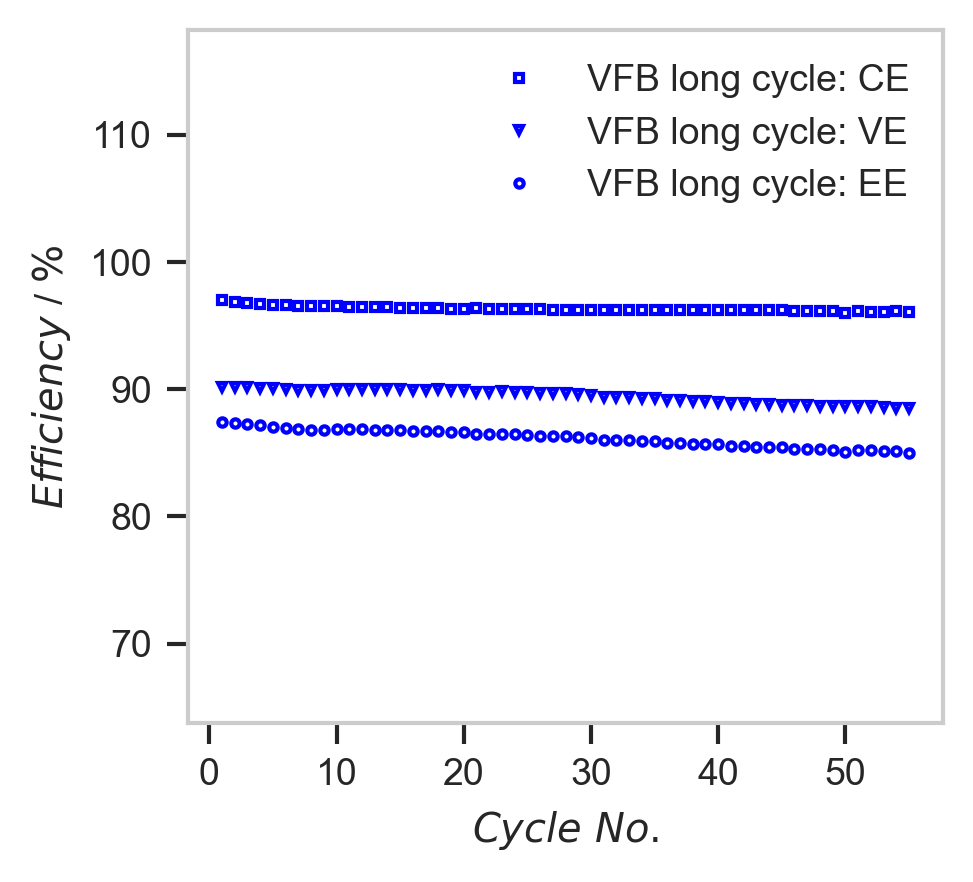

In [ ]:
j_plot = False

fpath=r"C:\Users\es758\Downloads\1_VFB_22rpm_06_GCPL_C04.mpr"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# label="VFB long cycle"
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.set_area(0.0005)  # m2
# Just for this one display
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(CyclingData_object.time_series.head(10))
    #display(CyclingData_object.time_series[CyclingData_object.time_series['cycle_number'] == 2])
    pass

# data = CyclingData_object.time_series
# # data = data[(data['cycle_number'] >= 15) & (data['cycle_number'] <= 17)]
# # GenericPlot_object = GenericPlot(x_col="time", y_col="Ewe/V", y2_col="control/V/mA")
# GenericPlot_object = GenericPlot(x_col="time", y_col="I_cell")
# GenericPlot_object.add_plot(data, linestyle = "-", marker = "", color1 = 'blue', color2='red', label = "VFB charge-discharge")
# GenericPlot_object.ax.legend()
# GenericPlot_object.ax.set_xlim([14268, 16000])
# display(GenericPlot_object.fig)

display(CyclingData_object.cycle_data.head(1))

EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi=300) 
EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=2, markerfacecolor='none', markeredgecolor='blue', color='blue', plot_CE=True, plot_VE=True, label="VFB long cycle")

if j_plot == True:
    EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

EfficiencyPlot_object.ax.legend()
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)
